# King County House Price Prediction

## Purpose
This notebook aims to build a machine learning model to predict house prices in King County, USA. We will perform exploratory data analysis, preprocess the data, build a neural network model using TensorFlow/Keras, and evaluate its performance.

**Experiment Link** --> https://colab.research.google.com/drive/1PNc8xkk0_j_5k5zjH3V0hniP0DneRSGk?usp=sharing

**Data set Link** --> https://drive.google.com/file/d/1KR727MiSZ1imRN_kngs-zwQk89AmImrP/view?usp=sharing

## Importing required Libraries

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,mean_absolute_error,explained_variance_score,r2_score
from sklearn.metrics import classification_report,confusion_matrix

## 1. Data Loading and Initial Inspection
This section focuses on loading the dataset and performing initial checks to understand its structure, identify missing values, and check for duplicates.

In [23]:
df = pd.read_csv("/content/kc_house_data.csv")

### Display First Rows
Viewing the first few rows helps in understanding the columns and the type of data they contain.

In [24]:
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


### Data Information
The `df.info()` method provides a concise summary of the DataFrame, including the number of non-null entries for each column and their data types. This is crucial for identifying missing data and inappropriate data types.

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

### DataFrame Shape
`df.shape` returns a tuple representing the dimensionality of the DataFrame (rows, columns).

In [26]:
columns_to_drop = ['id', 'zipcode', 'lat', 'long', 'sqft_above', 'sqft_basement', 'sqft_living15', 'sqft_lot15', 'date']
df = df.drop(columns=columns_to_drop, errors='ignore')

### Split Features (X) and Label (y)
The dataset is divided into features (`X`), which are the input variables used for prediction, and the label (`y`), which is the target variable we aim to predict (house `price`).

In [27]:
df.shape

(21613, 12)

### Descriptive Statistics
`df.describe()` generates descriptive statistics that summarize the central tendency, dispersion, and shape of a dataset's distribution, excluding `NaN` values.

In [28]:
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,yr_built,yr_renovated
count,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1971.005136,84.402258
std,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,29.373411,401.679240
min,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,1900.000000,0.000000
25%,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1951.000000,0.000000
50%,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1975.000000,0.000000
75%,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,1997.000000,0.000000
max,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,2015.000000,2015.000000


### Check for Missing Values
This step helps in identifying columns with missing data, which will need to be addressed during data preprocessing.

In [29]:
df.isnull().sum()

,0
price,0
bedrooms,0
bathrooms,0
sqft_living,0
sqft_lot,0
floors,0
waterfront,0
view,0
condition,0
grade,0


### Check for Duplicated Rows
Identifies and counts any duplicate rows in the dataset, which might indicate data entry errors or redundancy.

In [30]:
df.duplicated().sum()

np.int64(8)

## 2. Exploratory Data Analysis (EDA)
In this section, we will explore the relationships between different features and the target variable (`price`) using visualizations and correlation analysis.

### Pearson Correlation Matrix
A heatmap of the Pearson correlation matrix helps visualize the linear relationships between all numerical variables in the dataset. Values closer to 1 or -1 indicate a strong positive or negative correlation, respectively.

<Axes: title={'center': 'Pearson Correlation Matrix'}>

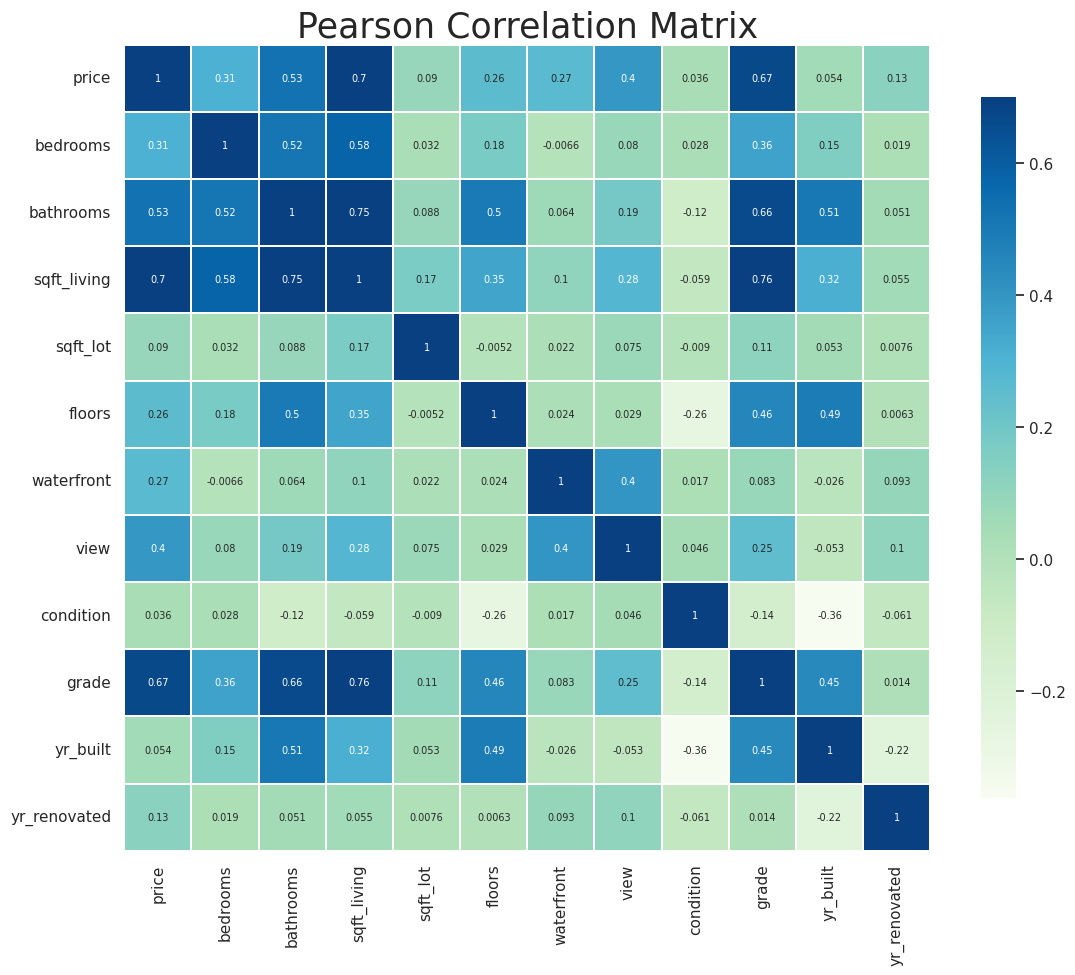

In [32]:
sns.set(style="whitegrid", font_scale=1)

plt.figure(figsize=(13,13))
plt.title('Pearson Correlation Matrix',fontsize=25)
sns.heatmap(df.corr(),linewidths=0.25,vmax=0.7,square=True,cmap="GnBu",linecolor='w',
            annot=True, annot_kws={"size":7}, cbar_kws={"shrink": .7})

### Correlation with Price
Here, we specifically look at how each feature correlates with the `price` of the houses, sorted from highest to lowest correlation.

In [34]:
price_corr = df.corr()['price'].sort_values(ascending=False)
print(price_corr)

price           1.000000
sqft_living     0.702035
grade           0.667434
bathrooms       0.525138
view            0.397293
bedrooms        0.308350
waterfront      0.266369
floors          0.256794
yr_renovated    0.126434
sqft_lot        0.089661
yr_built        0.054012
condition       0.036362
Name: price, dtype: float64


### Price Distribution and `sqft_living` vs. Price
These plots help us understand the distribution of house prices and the relationship between living area (`sqft_living`) and price. The distribution plot shows the overall spread of prices, while the scatter plot reveals how `sqft_living` influences price.

/tmp/ipykernel_1208/636539046.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price'], ax=axes[0])


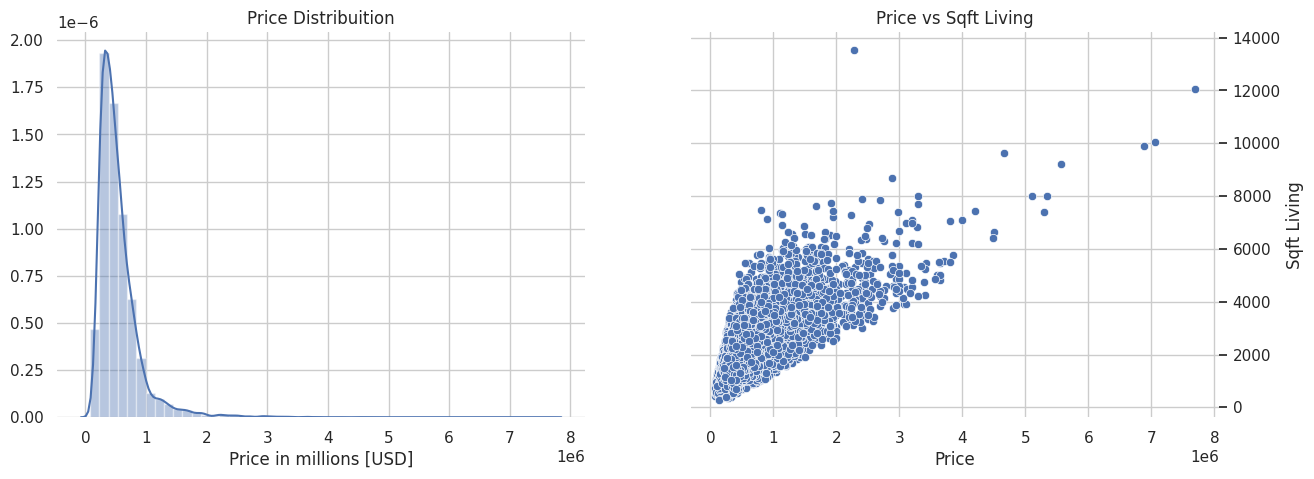

In [35]:
f, axes = plt.subplots(1, 2,figsize=(15,5))
sns.distplot(df['price'], ax=axes[0])
sns.scatterplot(x='price',y='sqft_living', data=df, ax=axes[1])
sns.despine(bottom=True, left=True)
axes[0].set(xlabel='Price in millions [USD]', ylabel='', title='Price Distribuition')
axes[1].set(xlabel='Price', ylabel='Sqft Living', title='Price vs Sqft Living')
axes[1].yaxis.set_label_position("right")
axes[1].yaxis.tick_right()

### Box Plots for Bedrooms and Floors vs. Price
Box plots are used to visualize the distribution of house prices across different categories of bedrooms and floors. They help in identifying potential relationships and outliers.

[Text(0.5, 0, 'Floors'),
 Text(0, 0.5, 'Price'),
 Text(0.5, 1.0, 'Floors vs Price Box Plot')]

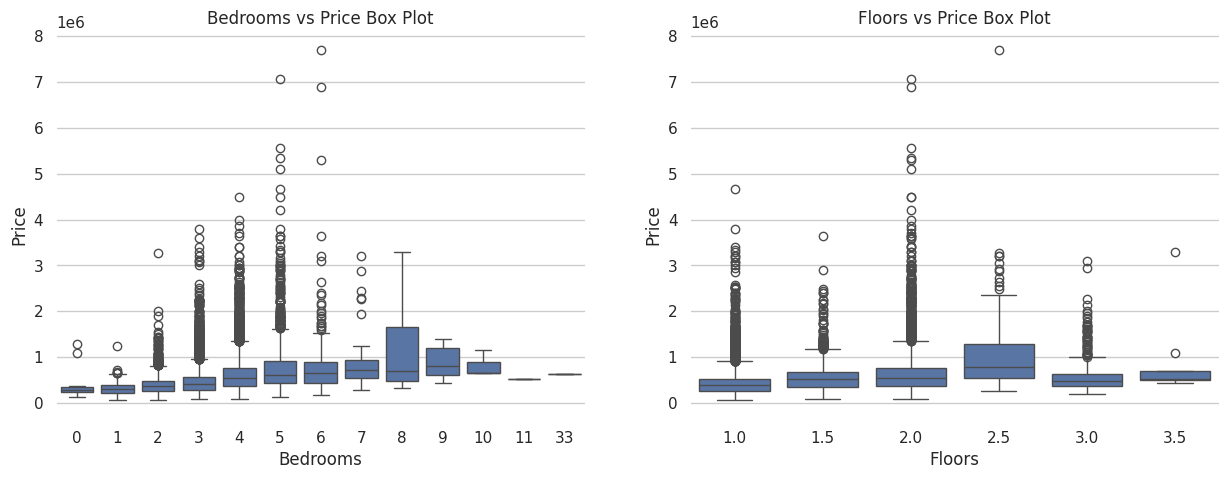

In [36]:
sns.set(style="whitegrid", font_scale=1)

f, axes = plt.subplots(1, 2,figsize=(15,5))
sns.boxplot(x=df['bedrooms'],y=df['price'], ax=axes[0])
sns.boxplot(x=df['floors'],y=df['price'], ax=axes[1])
sns.despine(bottom=True, left=True)
axes[0].set(xlabel='Bedrooms', ylabel='Price', title='Bedrooms vs Price Box Plot')
axes[1].set(xlabel='Floors', ylabel='Price', title='Floors vs Price Box Plot')

### Box Plots for Waterfront, View, and Grade vs. Price
Similar to the previous plots, these box plots analyze the impact of categorical features like `waterfront` (presence of a waterfront), `view` (quality of view), and `grade` (overall grade given to the housing unit) on the house price.

[Text(0.5, 0, 'Grade'),
 Text(0, 0.5, 'Price'),
 Text(0.5, 1.0, 'Grade vs Price Box Plot')]

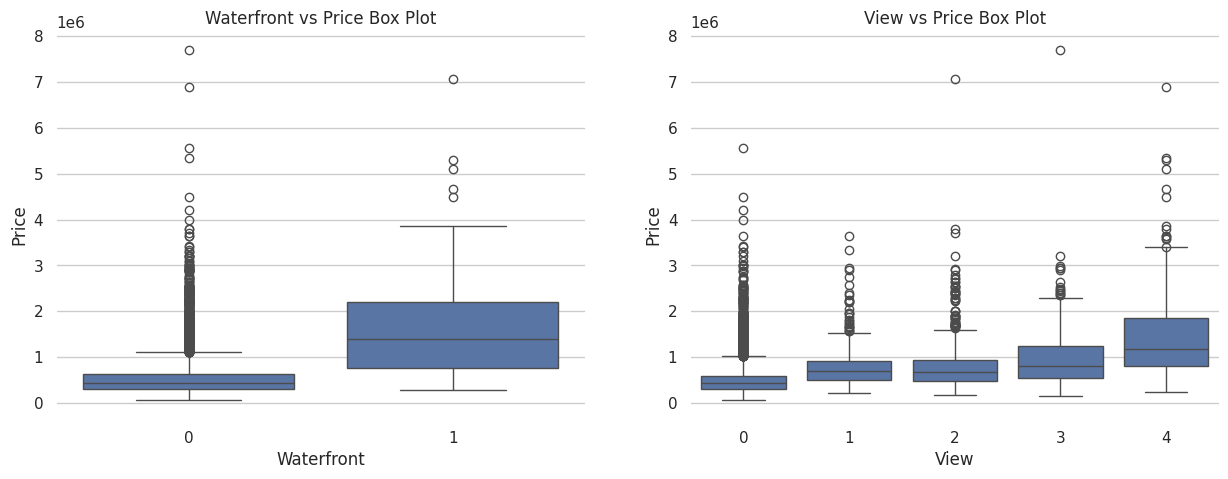

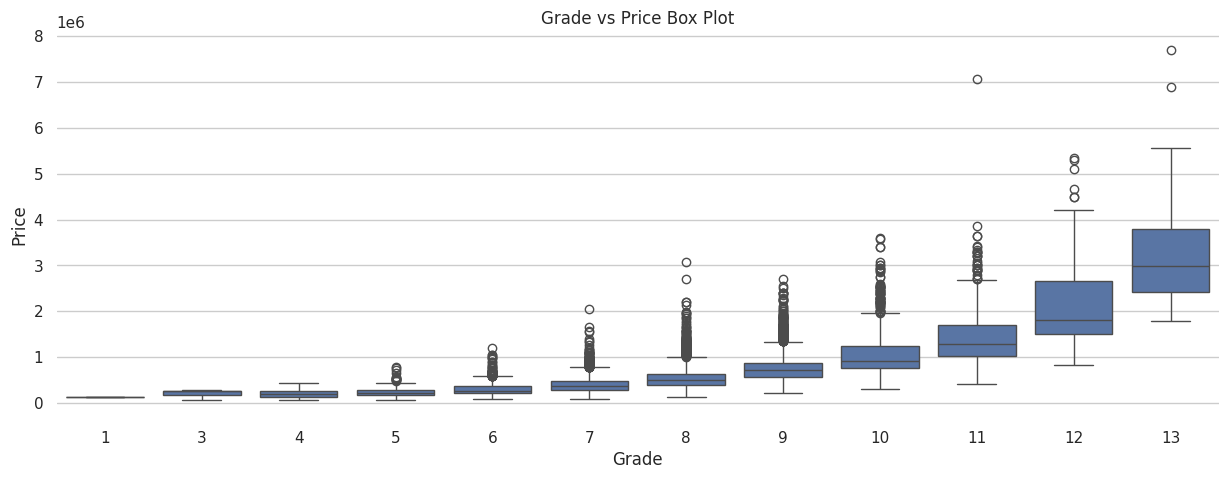

In [37]:
f, axes = plt.subplots(1, 2,figsize=(15,5))
sns.boxplot(x=df['waterfront'],y=df['price'], ax=axes[0])
sns.boxplot(x=df['view'],y=df['price'], ax=axes[1])
sns.despine(left=True, bottom=True)
axes[0].set(xlabel='Waterfront', ylabel='Price', title='Waterfront vs Price Box Plot')
axes[1].set(xlabel='View', ylabel='Price', title='View vs Price Box Plot')

f, axe = plt.subplots(1, 1,figsize=(15,5))
sns.boxplot(x=df['grade'],y=df['price'], ax=axe)
sns.despine(left=True, bottom=True)
axe.set(xlabel='Grade', ylabel='Price', title='Grade vs Price Box Plot')

## 3. Data Preprocessing
This section involves cleaning and preparing the data for model training, including dropping irrelevant columns, separating features and the target variable, and scaling features.

### Drop Irrelevant Columns
Based on the initial data inspection and correlation analysis, certain columns might be deemed irrelevant for price prediction or have already been extracted (like 'date'). These columns are dropped to simplify the model and potentially improve performance.

In [39]:
# Features
X = df.drop('price',axis=1)

# Label
y = df['price']

### Train-Test Split
The data is split into training and testing sets. The training set is used to train the model, while the testing set is used to evaluate its performance on unseen data, ensuring the model's generalization capability.

In [40]:
# Split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=101)

### Check Shapes of Split Data
Verifying the shapes of the training and testing sets ensures that the data has been split correctly into the expected dimensions.

In [41]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(15129, 11)
(6484, 11)
(15129,)
(6484,)


### Feature Scaling
Feature scaling (using `StandardScaler`) is applied to normalize the range of independent variables or features. This step is crucial for neural networks to ensure that all features contribute equally to the model training process, preventing features with larger values from dominating. The scaler is `fit` on the training data and then used to `transform` both training and test data.

In [42]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 4. Model Building and Training
This section covers defining the neural network architecture, compiling the model, and training it using the preprocessed data.

### Import Keras Components
Importing necessary classes from TensorFlow's Keras API to build a sequential neural network model.

In [44]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation
from tensorflow.keras.optimizers import Adam

### Define Model Architecture
A Sequential model is created with an input layer, multiple hidden dense layers with `relu` activation, and a final output layer with a single neuron for regression (predicting house price).

In [47]:
model = Sequential()

# input layer
model.add(Dense(19,activation='relu'))

# hidden layers
model.add(Dense(19,activation='relu'))
model.add(Dense(19,activation='relu'))
model.add(Dense(19,activation='relu'))

# output layer
model.add(Dense(1))



### Compile Model
The model is compiled using the `adam` optimizer and `mse` (Mean Squared Error) as the loss function, which is suitable for regression tasks.

In [62]:
model.compile(optimizer='adam',loss='mse',metrics=['r2_score'])

### Train Model
The model is trained using the `X_train` and `y_train` data. `validation_data` is provided to monitor performance on the test set during training. The `history` object captures training metrics per epoch.

In [63]:
history = model.fit(x=X_train,y=y_train.values,
          validation_data=(X_test,y_test.values),
          batch_size=128,epochs=170)

Epoch 1/170
119/119 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 38572462080.0000 - r2_score: 0.7087 - val_loss: 38037430272.0000 - val_r2_score: 0.7288
Epoch 2/170
119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 38539247616.0000 - r2_score: 0.7090 - val_loss: 38048645120.0000 - val_r2_score: 0.7288
Epoch 3/170
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 38514810880.0000 - r2_score: 0.7091 - val_loss: 38063566848.0000 - val_r2_score: 0.7286
Epoch 4/170
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 38543466496.0000 - r2_score: 0.7089 - val_loss: 37998637056.0000 - val_r2_score: 0.7291
Epoch 5/170
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 38428049408.0000 - r2_score: 0.7098 - val_loss: 38080319488.0000 - val_r2_score: 0.7285
Epoch 6/170
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 38497808384.0000 - r2_score: 0.7093 - val_loss: 37957238784.0000 - val_r2_score: 0.7294
Epoch 7/170
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 38467739648.0000 - r2_score: 0.7095 - val_lo

## 5. Model Evaluation
This final section evaluates the trained model's performance.

### Plot Training Loss
Visualizing the training and validation loss over epochs helps in understanding the model's learning process and detecting overfitting or underfitting.

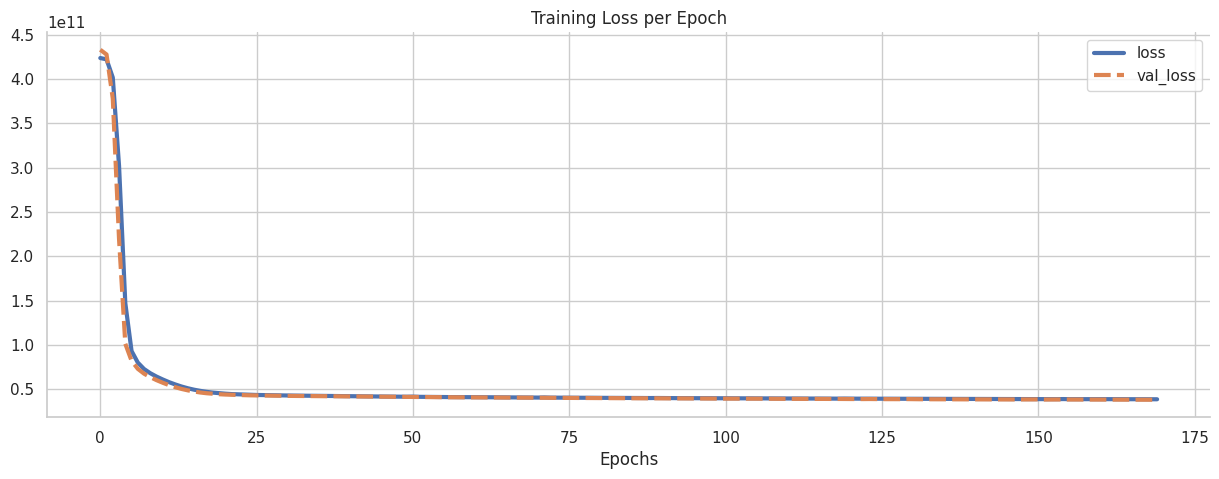

In [51]:
losses = pd.DataFrame(model.history.history)

plt.figure(figsize=(15,5))
sns.lineplot(data=losses,lw=3)
plt.xlabel('Epochs')
plt.ylabel('')
plt.title('Training Loss per Epoch')
sns.despine()

### Model Predictions
We use the trained model to make predictions on the `X_test` data and then inverse transform these predictions and the `y_test` data to get them back into the original price scale for more interpretable evaluation.

In [56]:
predictions = model.predict(X_test)
y_test_values = y_test.values.reshape(-1, 1) # Reshape for consistency if needed

203/203 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


### Regression Evaluation Metrics
Different metrics are used to evaluate the performance of a regression model. Here we calculate Mean Absolute Error (MAE), Mean Squared Error (MSE), and Root Mean Squared Error (RMSE) to assess the model's accuracy.

In [57]:
print('Mean Absolute Error:', mean_absolute_error(y_test_values, predictions))
print('Mean Squared Error:', mean_squared_error(y_test_values, predictions))
print('Root Mean Squared Error:', np.sqrt(mean_squared_error(y_test_values, predictions))) # Calculate RMSE

Mean Absolute Error: 129045.31978475864
Mean Squared Error: 38026426284.440216
Root Mean Squared Error: 195003.6571052969


### Explained Variance Score
 The explained variance regression score measures the proportion to which a mathematical model accounts for the variation (variance) of a given data set. A score of 1.0 indicates that the model perfectly explains the variance of the data.

In [58]:
print('Explained Variance Score:', explained_variance_score(y_test_values, predictions))

Explained Variance Score: 0.7289760454406273


### Visualize Predictions vs. True Values
A scatter plot comparing the true `y_test` values with the model's `predictions` helps visualize the model's accuracy. A perfect model would show all points lying on a straight diagonal line.

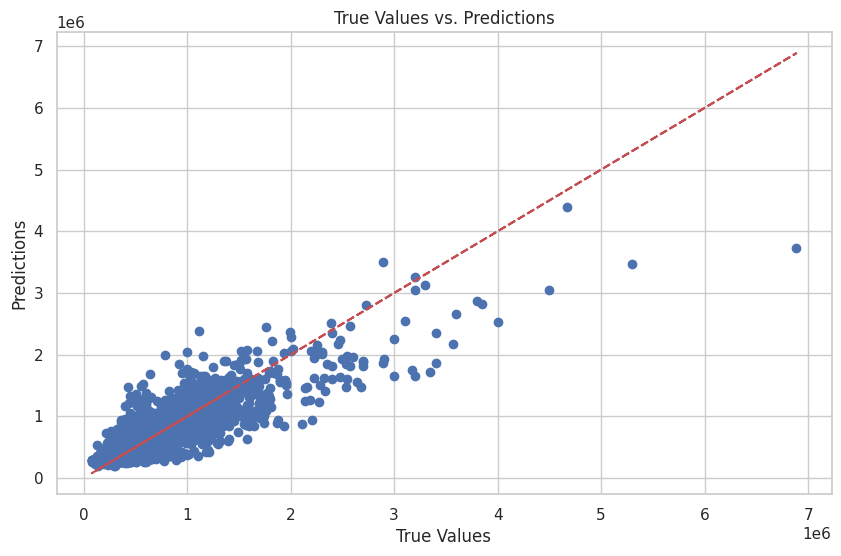

In [59]:
plt.figure(figsize=(10,6))
plt.scatter(y_test_values, predictions)
plt.plot(y_test_values, y_test_values, 'r--') # Add a red dashed line for perfect prediction
plt.xlabel('True Values')
plt.ylabel('Predictions')
plt.title('True Values vs. Predictions')
plt.show()